# Detecting Fraud in Mobile-Money Transfers

A guided walkthrough: we take 6.3 million simulated mobile-money transactions and build, step by step, a model
that flags the fraudulent ones. Every idea is introduced on a small example first, then applied to the full data.

**What you will be able to do by the end**

1. Explain why accuracy is useless when fraud is rare, and use precision, recall and PR-AUC instead.
2. Turn an accounting rule (a balance should move by exactly the amount sent) into model features.
3. Split data by time so that a model is tested on the future, not on the past it was trained on.
4. Read a small decision tree, then train and compare stronger models.
5. Choose a decision threshold from the cost of mistakes, and work out what precision really means when
   fraud is far rarer than in your test set.
6. Check whether a model holds up over time, and explain an individual decision with SHAP.

**Before you start**

- Data: [PaySim 1](https://www.kaggle.com/datasets/ealaxi/paysim1) from Kaggle (470 MB, not stored in this
  repository). Put `PS_20174392719_1491204439457_log.csv` next to this notebook, or set the `PAYSIM_CSV`
  environment variable to its path.
- Libraries: `pip install -r requirements.txt` (exact versions). Nothing is installed from inside the notebook.
- Time and memory: the stored run took 29 minutes on a 16 GB laptop with about 4 GB free; no GPU is needed.

**How to read it.** Each step says what we are about to do and why, runs one short cell, and then says what the
output tells us. Boxes marked **Try it** suggest a change to make and rerun; they are the quickest way to check
you understood a step.

This notebook is for learning and exploration. The model that is actually shipped (with tuning, calibration and
monitoring) lives in `src/`; the last section explains how the two differ.

*Provenance of the stored outputs:* the outputs below are from a full run finished on 6 October 2026, on the library versions pinned in `requirements.txt`. Every model score matches the previous stored run of this exploration (3 and 4 October); the notebook was rewritten as a walkthrough, and the stacking ensemble of earlier versions was dropped.

---
## 1. Set up

We load the libraries once, here. The settings cell after it holds everything you might want to change.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (average_precision_score, confusion_matrix, precision_recall_curve,
                             roc_auc_score)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.options.display.float_format = "{:,.2f}".format
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
SETTINGS = {
    "data_path": os.environ.get("PAYSIM_CSV", "PS_20174392719_1491204439457_log.csv"),
    "seed": 42,           # one seed, so every run gives the same numbers
    "split_step": 490,    # train on hours 1-490, test on hours 491-743 (section 6)
    "cost_ratio": 10,     # a missed fraud costs as much as 10 false alarms (section 10)
}
np.random.seed(SETTINGS["seed"])

N_JOBS = 1    # threads for the boosted models; more threads use more memory, results are the same
RF_JOBS = 4   # random forests share one copy of the data, so extra threads are cheap

---
## 2. Meet the data

**Step 2.1:** Load the file. If it is missing, the cell stops with instructions rather than quietly using
something else.

In [3]:
data_path = Path(SETTINGS["data_path"])
if not data_path.exists():
    raise FileNotFoundError(
        f"PaySim CSV not found at {data_path.resolve()}. Download 'PaySim 1' from "
        "https://www.kaggle.com/datasets/ealaxi/paysim1 and put it next to this notebook, "
        "or set PAYSIM_CSV to its path."
    )

df = pd.read_csv(data_path)

# PaySim's names are inconsistently capitalised (oldbalanceOrg, newbalanceOrig); make them consistent
df = df.rename(columns={"oldbalanceOrg": "oldBalanceOrig", "newbalanceOrig": "newBalanceOrig",
                        "oldbalanceDest": "oldBalanceDest", "newbalanceDest": "newBalanceDest"})
print(f"{len(df):,} transactions, {df.shape[1]} columns")
df.head()

6,362,620 transactions, 11 columns


,step,type,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


Each row is one transaction:

| Column | Meaning |
|---|---|
| `step` | Hour of the simulation, 1 to 743 (about 31 days) |
| `type` | TRANSFER, CASH_OUT, PAYMENT, CASH_IN or DEBIT |
| `amount` | Value of the transaction |
| `nameOrig`, `nameDest` | Sender and recipient account IDs (`C` customer, `M` merchant) |
| `oldBalanceOrig`, `newBalanceOrig` | Sender's balance before and after |
| `oldBalanceDest`, `newBalanceDest` | Recipient's balance before and after |
| `isFraud` | 1 if the transaction was fraud: the label we want to predict |
| `isFlaggedFraud` | 1 if PaySim's own built-in rule flagged it |

**Step 2.2:** Look closely at two fraudulent transactions, rows 2 and 3.

In [4]:
df.loc[[2, 3], ["type", "amount", "oldBalanceOrig", "newBalanceOrig", "oldBalanceDest", "newBalanceDest", "isFraud"]]

,type,amount,oldBalanceOrig,newBalanceOrig,oldBalanceDest,newBalanceDest,isFraud
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,CASH_OUT,181.00,181.00,0.00,"21,182.00",0.00,1


Work through them as an accountant would:

- **Row 2, a TRANSFER of 181.** The sender had 181 and ends with 0, so the whole balance left. But the recipient
  had 0 and still has 0: 181 left one account and arrived nowhere.
- **Row 3, a CASH_OUT of 181.** The sender again goes from 181 to 0. The recipient had 21,182 and ends with 0,
  so the recipient's balance *fell* while receiving money.

In an honest transaction the sender's balance falls by exactly the amount and the recipient's rises by exactly
the amount. Both frauds break that rule. Keep these two rows in mind; most of this notebook turns that
observation into something a model can use.

---
## 3. How rare is fraud, and why accuracy misleads

**Step 3.1:** Count the frauds.

In [5]:
n_fraud = int(df["isFraud"].sum())
print(f"frauds: {n_fraud:,} of {len(df):,} transactions ({n_fraud / len(df):.4%})")

frauds: 8,213 of 6,362,620 transactions (0.1291%)


About 1 transaction in 775 is fraud. Now consider the laziest possible "model": it says *not fraud* for every
transaction.

**Step 3.2:** Score that lazy model.

In [6]:
lazy_prediction = np.zeros(len(df), dtype=int)          # never flags anything
accuracy = (lazy_prediction == df["isFraud"]).mean()
frauds_caught = int(((lazy_prediction == 1) & (df["isFraud"] == 1)).sum())
print(f"accuracy: {accuracy:.2%}   frauds caught: {frauds_caught}")

accuracy: 99.87%   frauds caught: 0


99.87% accurate, and it catches nothing. So accuracy is the wrong yardstick for rare events. We use two
measures instead, both about the fraud class only:

- **Recall** = frauds caught / all frauds. *Of the real fraud, how much did we catch?*
- **Precision** = frauds caught / all transactions flagged. *When we raise an alarm, how often is it real?*

A small example: if a model flags 100 transactions, 90 of them are fraud, and there were 120 frauds in total,
then precision is 90/100 = 90% and recall is 90/120 = 75%. The lazy model has a recall of 0, which is the
number that exposes it.

---
## 4. Where fraud happens, and the built-in flag

**Step 4.1:** Count fraud by transaction type.

In [7]:
df.groupby("type")["isFraud"].agg(transactions="size", frauds="sum")

,transactions,frauds
type,,
CASH_IN,1399284,0
CASH_OUT,2237500,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,532909,4097


Fraud appears only in TRANSFER and CASH_OUT: money is transferred out of a victim's account, then cashed out.
The other three types contain no fraud at all, so we can set them aside.

**Step 4.2:** Before building anything, check the detector PaySim already provides, `isFlaggedFraud`. Any model
we build must beat it.

In [8]:
flagged = df["isFlaggedFraud"] == 1
caught = int((flagged & (df["isFraud"] == 1)).sum())
print(f"transactions flagged: {int(flagged.sum())}   frauds among them: {caught}")
print(f"recall of the built-in flag: {caught / n_fraud:.2%}")

transactions flagged: 16   frauds among them: 16
recall of the built-in flag: 0.19%


The built-in rule flags 16 transactions and catches about 0.2% of the fraud. It is not a usable detector, and it
uses information we do not need, so it is dropped from the inputs.

**Step 4.3:** Keep TRANSFER and CASH_OUT, separate the label from the inputs, and turn the type into a number.
The account IDs are dropped too: they are almost all unique, and the recipients of fraudulent transfers almost
never reappear as senders (3 times in 4,097 fraudulent transfers), so they carry no pattern a model could learn.

In [9]:
active = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
target = active["isFraud"]                                                       # what we predict
features = active.drop(columns=["isFraud", "isFlaggedFraud", "nameOrig", "nameDest"])
features["type"] = features["type"].map({"TRANSFER": 0, "CASH_OUT": 1}).astype("int8")
features["hour"] = (features["step"] % 24).astype("int8")                        # hour of the day, 0-23

print(f"kept {len(active):,} of {len(df):,} transactions, and all {int(target.sum()):,} frauds")

kept 2,770,409 of 6,362,620 transactions, and all 8,213 frauds


In [10]:
# Check: filtering removed transactions but not a single fraud
assert int(target.sum()) == n_fraud

We also added `hour`, the hour of the day. The next plot shows why it may help.

**Step 4.4:** Plot the fraud rate by hour of the day.

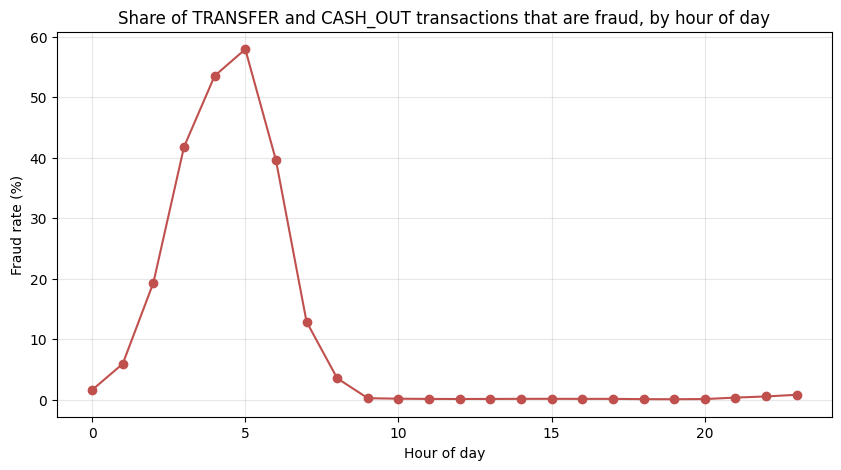

In [11]:
by_hour = target.groupby(features["hour"]).mean() * 100
by_hour.plot(marker="o", color="#c0504d")
plt.title("Share of TRANSFER and CASH_OUT transactions that are fraud, by hour of day")
plt.xlabel("Hour of day"); plt.ylabel("Fraud rate (%)"); plt.grid(alpha=0.3)
plt.show()

The rate jumps in the early hours of the morning. Fraud keeps going around the clock while honest activity drops
off at night, so a larger share of what happens at 3 a.m. is fraud.

---
## 5. Turn the ledger rule into features

Back to rows 2 and 3. The rule they broke can be written as two numbers that should be zero for an honest
transaction:

- `errorBalanceOrig` = new sender balance + amount - old sender balance
- `errorBalanceDest` = old recipient balance + amount - new recipient balance

**Step 5.1:** One complication first. Many recipient balances read 0 before *and* after a non-zero transfer
(row 2 is one). That is almost certainly "not recorded" rather than a real zero. Compare how often it happens
for fraud and for honest transactions.

In [12]:
zero_pair = (features["oldBalanceDest"] == 0) & (features["newBalanceDest"] == 0) & (features["amount"] > 0)
print(f"fraud with a 0 -> 0 recipient balance:  {zero_pair[target == 1].mean():.1%}")
print(f"honest with a 0 -> 0 recipient balance: {zero_pair[target == 0].mean():.2%}")

fraud with a 0 -> 0 recipient balance:  49.6%
honest with a 0 -> 0 recipient balance: 0.06%


Half of all frauds show the pattern, against well under 1% of honest transactions, so it is a signal worth
keeping. We mark those recipient balances with -1, a value that cannot occur naturally, instead of filling them
in. The same 0 -> 0 pattern on the sender's side is treated as genuinely unknown (`NaN`); tree models handle
missing values directly.

**Step 5.2:** Apply both, then compute the two error features.

In [13]:
features.loc[zero_pair, ["oldBalanceDest", "newBalanceDest"]] = -1

orig_zero_pair = (features["oldBalanceOrig"] == 0) & (features["newBalanceOrig"] == 0) & (features["amount"] > 0)
features.loc[orig_zero_pair, ["oldBalanceOrig", "newBalanceOrig"]] = np.nan

features["errorBalanceOrig"] = features["newBalanceOrig"] + features["amount"] - features["oldBalanceOrig"]
features["errorBalanceDest"] = features["oldBalanceDest"] + features["amount"] - features["newBalanceDest"]

features.loc[[2, 3], ["amount", "errorBalanceOrig", "errorBalanceDest"]]

,amount,errorBalanceOrig,errorBalanceDest
2,181.00,0.00,181.00
3,181.00,0.00,"21,363.00"


For our two frauds the sender-side error is 0 (the sender's balance fell by exactly 181), but the recipient
side is off: by 181 for row 2 (the money arrived nowhere; the -1 marker cancels out in the subtraction) and by
21,363 for row 3 (21,182 + 181 should have been there, and 0 is).

**Step 5.3:** Does that pattern hold across all transactions? Compare the destination error for fraud and
honest transactions, next to the raw amount.

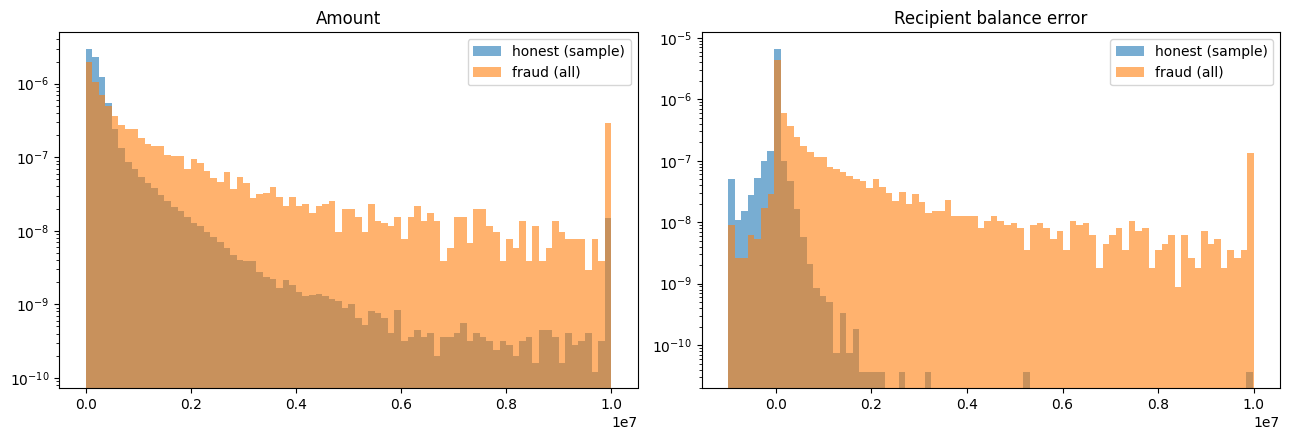

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sample = features.sample(200_000, random_state=SETTINGS["seed"]).index.union(features.index[target == 1])
for ax, col, title in [(axes[0], "amount", "Amount"), (axes[1], "errorBalanceDest", "Recipient balance error")]:
    values = features.loc[sample, col].clip(lower=-1e6, upper=1e7)
    ax.hist(values[target[sample] == 0], bins=80, alpha=0.6, density=True, label="honest (sample)")
    ax.hist(values[target[sample] == 1], bins=80, alpha=0.6, density=True, label="fraud (all)")
    ax.set_title(title); ax.set_yscale("log"); ax.legend()
plt.tight_layout(); plt.show()

The amounts of fraud and honest transactions overlap heavily, so the amount alone cannot separate them. The
recipient balance error looks different for the two groups. That is what the model will lean on.

---
## 6. Split by time: test on the future

A model is always used on transactions that happen *after* it was trained. If we shuffled the rows and split at
random, the model would train on hour 700 and be tested on hour 300, and its score would be better than anything
it could achieve in use. So we split by time:

```
hour 1 ............................ 490 | 491 ................ 743
              training (fit the model)  |  test (score it once)
```

`step` itself is left out of the inputs: every test hour is later than every training hour, so the model could
never have learned what to do with it. `hour` (0 to 23) repeats every day, so it stays.

**Step 6.1:** Split.

In [15]:
MODEL_COLS = [c for c in features.columns if c != "step"]
train_mask = features["step"] <= SETTINGS["split_step"]

X_train, y_train = features.loc[train_mask, MODEL_COLS], target[train_mask]
X_test, y_test = features.loc[~train_mask, MODEL_COLS], target[~train_mask]

print(f"training: {len(X_train):>9,} transactions, fraud rate {y_train.mean():.2%}")
print(f"test:     {len(X_test):>9,} transactions, fraud rate {y_test.mean():.2%}, {int(y_test.sum()):,} frauds")
print("model inputs:", MODEL_COLS)

training: 2,638,273 transactions, fraud rate 0.21%
test:       132,136 transactions, fraud rate 2.08%, 2,754 frauds
model inputs: ['type', 'amount', 'oldBalanceOrig', 'newBalanceOrig', 'oldBalanceDest', 'newBalanceDest', 'hour', 'errorBalanceOrig', 'errorBalanceDest']


In [16]:
# Check: every training transaction happened before every test transaction
assert features.loc[train_mask, "step"].max() < features.loc[~train_mask, "step"].min()

Notice the test window has about ten times the fraud rate of the training window: fraud continues at a similar
pace while honest volume falls away in the last days of the simulation. Keep this in mind in section 11.

---
## 7. A first model you can read

Before reaching for a powerful model, train one small enough to read: a decision tree that may ask only two
questions, about the two error features.

**Step 7.1:** Train the tree and print its rules.

In [17]:
from sklearn.tree import DecisionTreeClassifier, export_text

tree_cols = ["errorBalanceOrig", "errorBalanceDest"]
tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=SETTINGS["seed"])
tree.fit(X_train[tree_cols].fillna(0), y_train)
print(export_text(tree, feature_names=tree_cols))

|--- errorBalanceDest <= 61.52
|   |--- errorBalanceOrig <= 0.00
|   |   |--- class: 0
|   |--- errorBalanceOrig >  0.00
|   |   |--- class: 0
|--- errorBalanceDest >  61.52
|   |--- errorBalanceOrig <= 0.01
|   |   |--- class: 1
|   |--- errorBalanceOrig >  0.01
|   |   |--- class: 0



Read the rules from the top. The tree calls a transaction fraud when the recipient's balance is short by more
than about 62 *and* the sender's balance moved by exactly the amount (`errorBalanceOrig` close to 0). In words:
the sender's side of the ledger is clean, but the money never properly arrived. That is row 2 and row 3.

`class_weight="balanced"` tells the tree to treat the rare frauds as seriously as the many honest transactions;
without it, the tree would do best by calling everything honest, exactly like the lazy model of section 3.

**Step 7.2:** Score the tree on the test window with a confusion matrix: a count of every combination of truth
and prediction.

In [18]:
tree_flags = tree.predict(X_test[tree_cols].fillna(0))
cm = confusion_matrix(y_test, tree_flags)
print(pd.DataFrame(cm, index=["actually honest", "actually fraud"], columns=["flagged honest", "flagged fraud"]))
print(f"\nrecall:    {cm[1, 1] / cm[1].sum():.1%}")
print(f"precision: {cm[1, 1] / cm[:, 1].sum():.1%}")

                 flagged honest  flagged fraud
actually honest          129303             79
actually fraud             1387           1367

recall:    49.6%
precision: 94.5%


Two questions catch about half the test fraud, and roughly 19 out of 20 alarms are real. That is already far
beyond the built-in flag. The frauds it misses are the ones that need more than two questions.

> **Try it:** change `max_depth=2` to `max_depth=4` and rerun Steps 7.1 and 7.2. How do recall and precision
> move, and how much harder are the rules to read?

---
## 8. Measuring a detector properly

The tree gave one recall and one precision, at one cut-off. Most models output a **score** between 0 and 1, and
we choose the cut-off. Lower it and we catch more fraud (recall up) but raise more false alarms (precision
down). A **precision-recall curve** shows every cut-off at once, and **PR-AUC** (also called average precision)
summarises the curve in one number between 0 and 1. A model that guesses at random scores about the fraud rate
of the test set, here about 0.02.

**Step 8.1:** Write one scoring function so every model is measured the same way: PR-AUC, ROC-AUC, and the best
recall we can get while keeping precision at or above 99%.

In [19]:
results = {}


def score_model(name, scores):
    precision, recall, _ = precision_recall_curve(y_test, scores)
    recall_at_99 = recall[:-1][precision[:-1] >= 0.99].max() if (precision[:-1] >= 0.99).any() else 0.0
    results[name] = {"PR-AUC": average_precision_score(y_test, scores),
                     "ROC-AUC": roc_auc_score(y_test, scores),
                     "Recall at 99% precision": recall_at_99}
    print(f"{name:34s} PR-AUC {results[name]['PR-AUC']:.4f}   recall at 99% precision {recall_at_99:.4f}")

**Step 8.2:** Score two simple detectors. The first is the rule PaySim documents for its flag (a TRANSFER above
200,000), applied directly. The second is our two-question tree.

In [20]:
rule = ((X_test["type"] == 0) & (X_test["amount"] > 200_000)).astype(int)    # type 0 = TRANSFER
score_model("Baseline (200,000 TRANSFER rule)", rule)
score_model("Two-question tree", tree.predict_proba(X_test[tree_cols].fillna(0))[:, 1])

Baseline (200,000 TRANSFER rule)   PR-AUC 0.0283   recall at 99% precision 0.0000


Two-question tree                  PR-AUC 0.4892   recall at 99% precision 0.0000


The documented rule barely beats random guessing (about 0.03 against 0.02); the two-question tree reaches
about 0.49. These are the numbers the stronger models have to beat.

---
## 9. A stronger model: gradient-boosted trees

XGBoost builds hundreds of small trees, each one correcting the mistakes of the trees before it. It uses all
nine inputs, not just two.

**Step 9.1:** Weight the classes. In training there are about 482 honest transactions for every fraud, so we
tell XGBoost that each fraud counts as much as 482 honest ones (`scale_pos_weight`). The weight comes from the
training labels only; using the test labels would leak the answer into the model.

In [21]:
class_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"honest transactions per fraud in training: {class_weight:.1f}")

honest transactions per fraud in training: 482.3


**Step 9.2:** Train XGBoost with shallow trees (depth 3) and score it.

In [22]:
from xgboost import XGBClassifier

model = XGBClassifier(max_depth=3, scale_pos_weight=class_weight, n_jobs=N_JOBS)
model.fit(X_train, y_train)
xgb_scores = model.predict_proba(X_test)[:, 1]
score_model("XGBoost, class-weighted", xgb_scores)

XGBoost, class-weighted            PR-AUC 0.9989   recall at 99% precision 0.9989


PR-AUC rises from about 0.49 for the two-question tree to 0.9989, and the model keeps 99% precision while
catching almost every fraud. Section 11 asks whether a score this high should be believed.

---
## 10. Choosing the cut-off

A score is not a decision. Somebody has to pick the cut-off above which a transaction is frozen, and that is a
business choice about the cost of each kind of mistake.

**Step 10.1:** One common policy: catch as much fraud as possible while keeping precision at 99% or better.
Find that cut-off and look at the confusion matrix there.

In [23]:
precision, recall, thresholds = precision_recall_curve(y_test, xgb_scores)
eligible = precision[:-1] >= 0.99
best = int(eligible.nonzero()[0][recall[:-1][eligible].argmax()])
operating_threshold = float(thresholds[best])

flags = (xgb_scores >= operating_threshold).astype(int)
cm = confusion_matrix(y_test, flags)
print(f"cut-off: {operating_threshold:.4f}   precision {precision[best]:.4f}   recall {recall[best]:.4f}\n")
print(pd.DataFrame(cm, index=["actually honest", "actually fraud"], columns=["flagged honest", "flagged fraud"]))

cut-off: 0.3602   precision 0.9903   recall 0.9989

                 flagged honest  flagged fraud
actually honest          129355             27
actually fraud                3           2751


At this cut-off the model misses 3 frauds and raises 27 false alarms among about 129,000 honest test
transactions.

**Step 10.2:** A second policy weighs the two mistakes directly. Suppose a missed fraud costs 10 times as much as
a false alarm (`SETTINGS["cost_ratio"]`). Try every cut-off and keep the cheapest.

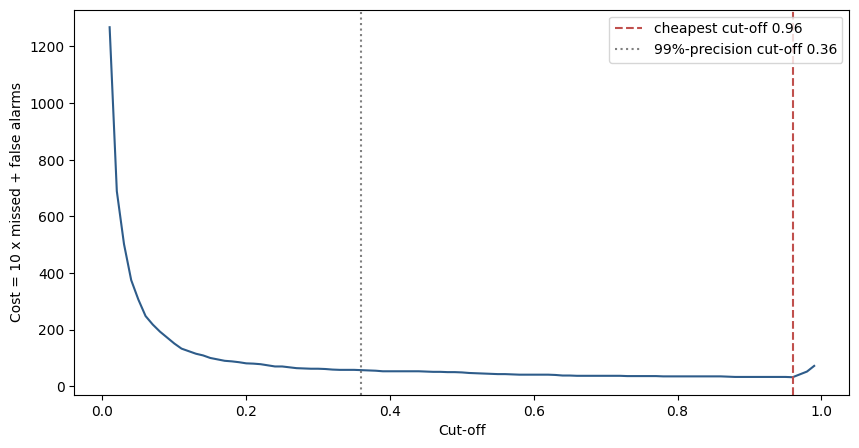

cheapest cut-off 0.96: 3 missed, 2 false alarms


In [24]:
cutoffs = np.linspace(0.01, 0.99, 99)
missed = np.array([int(((xgb_scores < c) & (y_test == 1)).sum()) for c in cutoffs])
false_alarms = np.array([int(((xgb_scores >= c) & (y_test == 0)).sum()) for c in cutoffs])
cost = SETTINGS["cost_ratio"] * missed + false_alarms
cheapest = int(cost.argmin())

plt.plot(cutoffs, cost, color="#2e5c8a")
plt.axvline(cutoffs[cheapest], color="#c0504d", linestyle="--", label=f"cheapest cut-off {cutoffs[cheapest]:.2f}")
plt.axvline(operating_threshold, color="gray", linestyle=":", label=f"99%-precision cut-off {operating_threshold:.2f}")
plt.xlabel("Cut-off"); plt.ylabel(f"Cost = {SETTINGS['cost_ratio']} x missed + false alarms"); plt.legend()
plt.show()
print(f"cheapest cut-off {cutoffs[cheapest]:.2f}: {missed[cheapest]} missed, {false_alarms[cheapest]} false alarms")

The two policies pick different cut-offs, and neither is "correct": the cost ratio has to come from the
business that will run the model. (The shipped pipeline assumes 100 to 1.)

> **Try it:** set `"cost_ratio": 100` in the settings cell, rerun the settings cell and Step 10.2. Where does the
> cheapest cut-off move, and why?

### 10.3 What precision really means in use

Our test window is unusually fraud-heavy: about 2.1% of its transactions are fraud, against about 0.3% of all
TRANSFER and CASH_OUT transactions across the whole month (the only types the model screens). Precision depends
on that mix. If fraud is rarer, the same model meets more honest transactions per
fraud, so the same false-alarm *rate* produces more false alarms per real one.

**Step 10.3:** Take the model's two rates from the test window (the share of frauds it catches, and the share of
honest transactions it wrongly flags) and apply them to a million screened transactions at the whole-month
fraud rate.

In [25]:
catch_rate = cm[1, 1] / cm[1].sum()            # share of frauds flagged
false_alarm_rate = cm[0, 1] / cm[0].sum()      # share of honest transactions flagged
real_fraud_rate = target.mean()                # TRANSFER and CASH_OUT over the whole month, about 0.3%

frauds = 1_000_000 * real_fraud_rate
caught = catch_rate * frauds
false_alarms = false_alarm_rate * (1_000_000 - frauds)
print(f"per million transactions: {frauds:,.0f} frauds, {caught:,.0f} caught, {false_alarms:,.0f} false alarms")
print(f"precision at the real fraud rate: {caught / (caught + false_alarms):.1%}  (on the test window: {precision[best]:.1%})")

per million transactions: 2,965 frauds, 2,961 caught, 208 false alarms
precision at the real fraud rate: 93.4%  (on the test window: 99.0%)


At the whole-month fraud rate, roughly one alarm in fifteen would be a false one, not one in a hundred.
Nothing about the model changed; only the mix of transactions did. An operations team sizing its review queue
needs this number, not the test-window precision. The shipped pipeline reports the same calculation for its own
model (`precision_at_real_fraud_rate` in `dashboard/data/business_impact.json`).

---
## 11. Comparing other model families

Is XGBoost special, or would other models do as well? We train three more, all scored by the same function.

**Step 11.1:** Logistic regression, a linear model. It cannot take missing values, so the sender-side `NaN`s are
filled with 1 (a value that cannot be confused with a real balance or with the -1 marker), and every input is
rescaled to a similar range.

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic = Pipeline([
    ("fill", SimpleImputer(strategy="constant", fill_value=1)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
logistic.fit(X_train, y_train)
score_model("Logistic regression", logistic.predict_proba(X_test)[:, 1])

Logistic regression                PR-AUC 0.7901   recall at 99% precision 0.4503


**Step 11.2:** A random forest: hundreds of deep trees, each trained on a random sample, voting together.

In [27]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_leaf=20,
                                class_weight="balanced_subsample", n_jobs=RF_JOBS, random_state=42)
forest.fit(X_train, y_train)
score_model("Random forest", forest.predict_proba(X_test)[:, 1])

Random forest                      PR-AUC 1.0000   recall at 99% precision 1.0000


**Step 11.3:** LightGBM, another gradient-boosting library, with the same class weight and larger trees.

In [28]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05, min_child_samples=5,
                      scale_pos_weight=class_weight, n_jobs=N_JOBS, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
score_model("LightGBM", lgbm.predict_proba(X_test)[:, 1])

LightGBM                           PR-AUC 0.0338   recall at 99% precision 0.0000


**Step 11.4:** Put them side by side.

In [29]:
scoreboard = pd.DataFrame(results).T.sort_values("PR-AUC", ascending=False)
print(scoreboard.to_string(float_format=lambda v: f"{v:.4f}"))

                                  PR-AUC  ROC-AUC  Recall at 99% precision
Random forest                     1.0000   1.0000                   1.0000
XGBoost, class-weighted           0.9989   0.9990                   0.9989
Logistic regression               0.7901   0.9795                   0.4503
Two-question tree                 0.4892   0.8694                   0.0000
LightGBM                          0.0338   0.6956                   0.0000
Baseline (200,000 TRANSFER rule)  0.0283   0.5888                   0.0000


Three lessons are in this table.

1. **A perfect score is a warning, not a win.** The random forest reaches PR-AUC 1.0000. Real fraud is never
   this separable. PaySim generates fraud by a simple process, and once the error features exist the label
   follows from them almost exactly. On a simulator, the scores show that the method works; they do not tell
   you how accurate a model would be on a real network.
2. **Models can fail quietly.** LightGBM, with deep trees, few rows per leaf and a large class weight, falls to
   about 0.03, no better than the 200,000 rule, without any error message. Remember the test window has ten
   times the fraud rate of training (section 6); a model tuned too tightly to the training window can break
   on a shift like that. Always score on later data before trusting a model.
3. **A linear model is not enough here.** Logistic regression ranks well overall but cannot keep 99% precision
   while catching most fraud, most likely because the fraud pattern ("this error is zero *and* that one is
   not") is a combination that a linear model cannot express directly.

---
## 12. Does it hold up over time?

A single test score hides change over time. Split the test window into four periods and score XGBoost on each,
keeping the cut-off chosen in Step 10.1 fixed, as it would be in use.

**Step 12.1:** Score each period.

In [30]:
test_steps = features.loc[~train_mask, "step"].to_numpy()
rows = []
for start, end in [(491, 560), (561, 630), (631, 700), (701, 743)]:
    in_period = (test_steps >= start) & (test_steps <= end)
    truth, scores = y_test.to_numpy()[in_period], xgb_scores[in_period]
    flagged = scores >= operating_threshold
    rows.append({"hours": f"{start}-{end}", "transactions": int(in_period.sum()), "frauds": int(truth.sum()),
                 "PR-AUC": average_precision_score(truth, scores),
                 "precision": (flagged & (truth == 1)).sum() / max(flagged.sum(), 1),
                 "recall": (flagged & (truth == 1)).sum() / truth.sum()})
print(pd.DataFrame(rows).set_index("hours").to_string(float_format=lambda v: f"{v:.4f}"))

         transactions  frauds  PR-AUC  precision  recall
hours                                                   
491-560         50526     726  1.0000     0.9878  1.0000
561-630         43619     764  0.9986     0.9858  0.9987
631-700         32774     774  0.9975     0.9910  0.9974
701-743          5217     490  1.0000     1.0000  1.0000


Ranking (PR-AUC) and recall stay close to perfect in every period, and precision stays between about 98.6% and
100% at the fixed cut-off, even though the mix shifts sharply: the last period has a tenth of the transactions
of the first, and nearly one in ten of them is fraud. On real data this check would be run every week, and a fall in
precision or recall would trigger a review of the cut-off or a retrain. The shipped pipeline does a stricter
version (`src/validate.py` retrains on expanding windows; `src/monitoring.py` tracks how the inputs drift).

---
## 13. Is resampling better than class weights?

A common textbook alternative to class weights is SMOTE: create synthetic frauds by drawing points between real
frauds until the classes are balanced. One worry for time-ordered data is that it mixes frauds from different
periods.

**Step 13.1:** Resample the training data with SMOTE and train the same XGBoost on it, with no class weight
(the classes are now balanced). SMOTE cannot handle missing values, so they are filled with -1 first.

In [31]:
from imblearn.over_sampling import SMOTE

X_train_filled, X_test_filled = X_train.fillna(-1), X_test.fillna(-1)
X_smote, y_smote = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train_filled, y_train)
print(f"training rows: {len(X_train_filled):,} -> {len(X_smote):,}; frauds: {int(y_train.sum()):,} -> {int(y_smote.sum()):,}")

smote_model = XGBClassifier(max_depth=3, scale_pos_weight=1, n_jobs=N_JOBS).fit(X_smote, y_smote)
score_model("XGBoost + SMOTE", smote_model.predict_proba(X_test_filled)[:, 1])

training rows: 2,638,273 -> 5,265,628; frauds: 5,459 -> 2,632,814


XGBoost + SMOTE                    PR-AUC 0.9995   recall at 99% precision 0.9949


SMOTE scores 0.9995 against 0.9989 for class weighting, a difference of 0.06 points, and it doubled the training
data to get there. On this data the two approaches are equivalent; class weights are the cheaper choice. (The
comparison also changed how missing values are handled, so it does not settle the question in general.)

---
## 14. Explaining one decision

If a customer's money is frozen, someone has to say why. **SHAP** splits a model's score for one transaction
into a contribution from each input, measured against an average transaction: positive values push towards
fraud, negative towards honest.

**Step 14.1:** Explain the highest-scoring fraud in the test window and one ordinary honest transfer.

In [32]:
warnings.filterwarnings("ignore", message="IProgress not found")   # SHAP's progress bar, not the analysis
import shap

explainer = shap.TreeExplainer(model)
fraud_row = X_test[y_test == 1].iloc[[int(np.argmax(xgb_scores[(y_test == 1).to_numpy()]))]]
honest_row = X_test[(y_test == 0) & (X_test["type"] == 0)].iloc[[0]]

for label, row in [("fraud", fraud_row), ("honest", honest_row)]:
    contributions = pd.Series(explainer.shap_values(row)[0], index=MODEL_COLS)
    top = contributions.reindex(contributions.abs().sort_values(ascending=False).index)[:3]
    print(f"{label} transaction, score {model.predict_proba(row)[0, 1]:.4f}; largest pushes:")
    for name, value in top.items():
        print(f"   {name:18s} value {row[name].iloc[0]:>14,.2f}   push {value:+.2f}")

fraud transaction, score 1.0000; largest pushes:
   newBalanceDest     value          -1.00   push +35.86
   oldBalanceOrig     value     449,199.47   push +20.23
   errorBalanceOrig   value           0.00   push +19.30
honest transaction, score 0.0000; largest pushes:
   errorBalanceOrig   value     834,162.12   push -15.63
   amount             value     954,064.12   push +3.15
   oldBalanceOrig     value     119,902.00   push -1.70


**Step 14.2:** Average the size of the pushes over 2,000 test transactions to see which inputs matter most
overall.

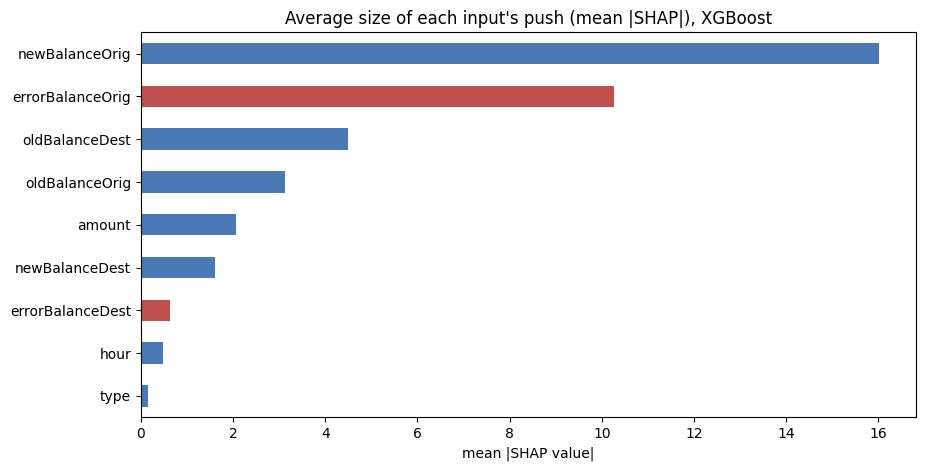

newBalanceOrig     16.01
errorBalanceOrig   10.26
oldBalanceDest      4.50
oldBalanceOrig      3.12
amount              2.07
newBalanceDest      1.61
errorBalanceDest    0.62
hour                0.48
type                0.15


In [33]:
shap_sample = X_test.sample(2_000, random_state=42)
importance = pd.Series(np.abs(explainer.shap_values(shap_sample)).mean(axis=0), index=MODEL_COLS).sort_values()
importance.plot(kind="barh", color=["#c0504d" if c.startswith("error") else "#4a7ab5" for c in importance.index])
plt.title("Average size of each input's push (mean |SHAP|), XGBoost"); plt.xlabel("mean |SHAP value|")
plt.show()
print(importance.sort_values(ascending=False).round(3).to_string())

The sender-side error feature is near the top, as the ledger reasoning predicted, but the raw sender balance
matters most. That is a warning sign: in PaySim almost every fraud empties the sender's account, so "the
balance went to zero" works as a shortcut. It would also flag an honest customer closing their own account. The
shipped pipeline removes the raw balances for this reason (next section).

---
## 15. From this notebook to the shipped model

This notebook is for learning, so it keeps things that the shipped pipeline in `src/` changes:

| | This notebook | Shipped pipeline (`src/`) |
|---|---|---|
| Inputs | 9, including the raw balances and the hour | 5: the amount, the two balance errors, and two ratios (how much of the sender's balance moved, and the amount against the recipient's balance) |
| Raw balances | Kept, to show what they do | Removed: the model used "balance hits zero" as a shortcut |
| Settings | Library defaults, class weight 482 | Tuned on earlier windows only (35 trees, class weight 2.14) |
| Probabilities | Raw model scores | Calibrated, so a score of 0.9 means about a 90% chance |
| Cut-off | 99% precision on the test window | Cheapest at a 100:1 cost ratio, chosen on calibration data before the test window |
| Over time | Four test periods, cut-off fixed | Four expanding retraining windows, plus input-drift monitoring |

The README and `docs/METHODOLOGY.md` report the shipped model's results; this notebook explains the ideas
behind it.

## What you learned

- Accuracy hides rare events; recall, precision and PR-AUC do not (sections 3 and 8).
- A domain rule, here the accounting identity, can become the most useful feature (section 5).
- Split by time, keep the split variable out of the inputs, and score once on the future (section 6).
- Start with a model you can read; it sets a baseline and shows what the data is saying (section 7).
- The cut-off is a business decision, and precision must be restated at the real fraud rate (section 10).
- A perfect score on simulated data is a warning; a quiet collapse on later data is a reason to test on it
  (section 11).
- Check performance period by period, and explain individual decisions (sections 12 and 14).

**Exercises**

1. Remove `oldBalanceOrig` and `newBalanceOrig` from `MODEL_COLS`, rerun from Step 6.1, and compare XGBoost's
   PR-AUC and the SHAP chart with the version above.
2. Change `"split_step"` to 600. How do the training fraud rate and the test results change?
3. In Step 10.3, set `real_fraud_rate` to 0.005 and to 0.0005. How does precision move, and what does that mean
   for a team that can review 50 alerts a day?

## Glossary

- **Precision / recall:** of the alarms raised, the share that are fraud / of the frauds, the share caught.
- **PR-AUC (average precision):** one number summarising precision and recall over every cut-off; random
  guessing scores the fraud rate.
- **ROC-AUC:** the chance a random fraud scores above a random honest transaction; looks high even for weak
  fraud models because honest transactions are so many.
- **Class weight:** how much more a mistake on the rare class counts during training.
- **Cut-off (threshold):** the score above which a transaction is flagged.
- **SMOTE:** a resampling method that creates synthetic examples of the rare class.
- **SHAP value:** one input's contribution to one prediction, against an average prediction.